In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud

# NLTK pour stopwords français
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords


sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Imports OK')

Imports OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/TER/Data/reddit/fr_EOHL_Reddit_prediction.xlsx'


Mounted at /content/drive


In [36]:
# ─────────────────────────────────────────────
#  CONFIGURATION — à modifier selon ton CSV
# ─────────────────────────────────────────────
CSV_PATH  = path
TEXT_COL  = 'text'            # nom de la colonne texte
LABEL_COL = 'Perspective_label'    # nom de la colonne label (0/1 ou haineux/non-haineux)
ENCODING  = 'utf-8'           # encodage (essaie 'latin-1' si erreur)
# ─────────────────────────────────────────────

df = pd.read_excel(CSV_PATH)

print(f'📦 Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\n📋 Colonnes : {list(df.columns)}')
df.head()

📦 Shape : 20,000 lignes × 3 colonnes

📋 Colonnes : ['text', 'Perspective_probability', 'Perspective_label']


,text,Perspective_probability,Perspective_label
0,"C'est dingue, après tout ce temps, plus de 15 ...",0.041915,0
1,"Plutôt d'accord pour les SAV, c'est le but mêm...",0.008671,0
2,Bordel. J'avais tapé une longue réponse. Une f...,0.110887,0
3,Non pas de problème de ce côté là heureusement !,0.004021,0
4,&gt;Les violences étaient clairement motivées ...,0.254629,0


# 2. Apercu general

In [37]:
print('='*55)
print('INFOS GÉNÉRALES')
print('='*55)
df.info()
print()
print('─'*55)
print('TYPES DES COLONNES')
print(df.dtypes)
print()
print('─'*55)


INFOS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   text                     19498 non-null  object 
 1   Perspective_probability  19999 non-null  float64
 2   Perspective_label        20000 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 468.9+ KB

───────────────────────────────────────────────────────
TYPES DES COLONNES
text                        object
Perspective_probability    float64
Perspective_label            int64
dtype: object

───────────────────────────────────────────────────────


In [38]:
df[TEXT_COL].apply(type).value_counts()

,count
text,
<class 'str'>,19491
<class 'float'>,502
<class 'int'>,6
<class 'bool'>,1


In [39]:
df[TEXT_COL] = df[TEXT_COL].where(df[TEXT_COL].notnull(), '').astype(str)

In [40]:
print('='*55)
print('VALEURS MANQUANTES')
print('='*55)
nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'count': nulls, 'pct (%)': pct})
print(null_df[null_df['count'] > 0] if null_df['count'].sum() > 0 else '✅ Aucune valeur manquante')

print()
print('='*55)
print('DOUBLONS')
print('='*55)
n_dup_full  = df.duplicated().sum()
n_dup_text  = df[TEXT_COL].duplicated().sum()
print(f'Lignes entièrement dupliquées : {n_dup_full:,} ({n_dup_full/len(df)*100:.1f}%)')
print(f'posts dupliqués (texte seul) : {n_dup_text:,} ({n_dup_text/len(df)*100:.1f}%)')

# Exemples de doublons si présents
if n_dup_text > 0:
    print('\nExemples de posts dupliqués :')
    dup_examples = df[df[TEXT_COL].duplicated(keep=False)].sort_values(TEXT_COL).head(6)
    display(dup_examples[[TEXT_COL, LABEL_COL]])

VALEURS MANQUANTES
                         count  pct (%)
Perspective_probability      1      0.0

DOUBLONS
Lignes entièrement dupliquées : 739 (3.7%)
posts dupliqués (texte seul) : 742 (3.7%)

Exemples de posts dupliqués :


,text,Perspective_label
29,,0
11501,,0
11503,,0
11516,,0
11547,,0
11591,,0


In [41]:
print('='*55)
print('LABELS — valeurs uniques')
print('='*55)
print(df[LABEL_COL].value_counts())
print(f'\nType du label : {df[LABEL_COL].dtype}')

LABELS — valeurs uniques
Perspective_label
0      19715
1        284
284        1
Name: count, dtype: int64

Type du label : int64


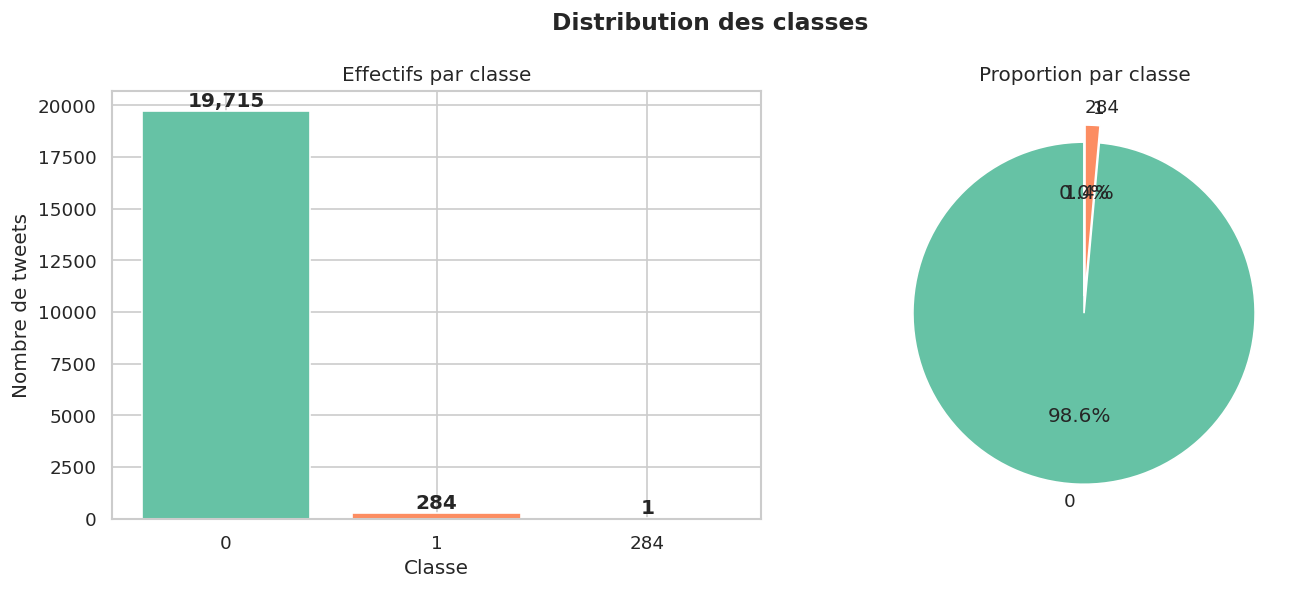


📊 Résumé des classes :
                   Effectif  Proportion (%)
Perspective_label                          
0                     19715            98.6
1                       284             1.4
284                       1             0.0

⚠️ Ratio majorité/minorité : 19715.0


In [42]:
counts = df[LABEL_COL].value_counts()
pcts   = df[LABEL_COL].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution des classes', fontsize=14, fontweight='bold')

# Barplot
bars = axes[0].bar(counts.index.astype(str), counts.values,
                   color=sns.color_palette('Set2', len(counts)))
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de tweets')
axes[0].set_title('Effectifs par classe')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index.astype(str),
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(counts)),
            startangle=90, explode=[0.05]*len(counts))
axes[1].set_title('Proportion par classe')

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print('\n📊 Résumé des classes :')
summary = pd.DataFrame({'Effectif': counts, 'Proportion (%)': pcts.round(1)})
print(summary)

# Alerte déséquilibre
ratio = counts.max() / counts.min()
print(f'\n⚠️ Ratio majorité/minorité : {ratio:.1f}')

# Analyse de la longueur des posts

In [43]:
df['nb_chars']  = df[TEXT_COL].str.len()
df['nb_words']  = df[TEXT_COL].str.split().str.len()
df['nb_tokens'] = df[TEXT_COL].str.split().str.len()  # même chose ici, à affiner avec tokenizer

print('='*55)
print('LONGUEUR DES POSTS')
print('='*55)
for col, label in [('nb_chars', 'Caractères'), ('nb_words', 'Mots')]:
    print(f'\n{label} :')
    print(df[col].describe().round(1).to_string())

LONGUEUR DES POSTS

Caractères :
count    20000.0
mean       284.8
std        572.4
min          0.0
25%         59.0
50%        138.0
75%        309.0
max      16999.0

Mots :
count    20000.0
mean        47.9
std         91.7
min          0.0
25%         10.0
50%         24.0
75%         53.0
max       2216.0


In [44]:
# Supprimer les lignes où le texte est manquant
n_before = len(df)
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
n_after = len(df)

print(f"Lignes avant : {n_before}")
print(f"Lignes après  : {n_after}")
print(f"Lignes supprimées (texte manquant) : {n_before - n_after}")

Lignes avant : 20000
Lignes après  : 20000
Lignes supprimées (texte manquant) : 0


In [45]:
print("="*60)
print("DOUBLONS — vérification")
print("="*60)

# 1) Doublons sur TEXT_COL seul
dup_text_total = df.duplicated(subset=[TEXT_COL], keep=False).sum()      # lignes impliquées
dup_text_extra = df.duplicated(subset=[TEXT_COL], keep='first').sum()    # doublons "en trop"

print(f"\n1) Doublons sur [{TEXT_COL}]")
print(f"   - Lignes impliquées : {dup_text_total:,}")
print(f"   - Lignes dupliquées (hors 1ère occurrence) : {dup_text_extra:,}")

if dup_text_total > 0:
    print("\n   Exemples :")
    display(df[df.duplicated(subset=[TEXT_COL], keep=False)]
            .sort_values(TEXT_COL)
            [[TEXT_COL, LABEL_COL]]
            .head(10))

# 2) Doublons sur TEXT_COL + LABEL_COL
dup_text_label_total = df.duplicated(subset=[TEXT_COL, LABEL_COL], keep=False).sum()
dup_text_label_extra = df.duplicated(subset=[TEXT_COL, LABEL_COL], keep='first').sum()

print(f"\n2) Doublons sur [{TEXT_COL}, {LABEL_COL}]")
print(f"   - Lignes impliquées : {dup_text_label_total:,}")
print(f"   - Lignes dupliquées (hors 1ère occurrence) : {dup_text_label_extra:,}")

if dup_text_label_total > 0:
    print("\n   Exemples :")
    display(df[df.duplicated(subset=[TEXT_COL, LABEL_COL], keep=False)]
            .sort_values([TEXT_COL, LABEL_COL])
            [[TEXT_COL, LABEL_COL]]
            .head(10))

DOUBLONS — vérification

1) Doublons sur [text]
   - Lignes impliquées : 802
   - Lignes dupliquées (hors 1ère occurrence) : 742

   Exemples :


DOUBLONS — vérification

1) Doublons sur [text]
   - Lignes impliquées : 802
   - Lignes dupliquées (hors 1ère occurrence) : 742

   Exemples :


,text,Perspective_label
29,,0
11501,,0
11503,,0
11516,,0
11547,,0
11591,,0
11603,,0
11635,,0
11638,,0
11759,,0


DOUBLONS — vérification

1) Doublons sur [text]
   - Lignes impliquées : 802
   - Lignes dupliquées (hors 1ère occurrence) : 742

   Exemples :


,text,Perspective_label
29,,0
11501,,0
11503,,0
11516,,0
11547,,0
11591,,0
11603,,0
11635,,0
11638,,0
11759,,0



2) Doublons sur [text, Perspective_label]
   - Lignes impliquées : 801
   - Lignes dupliquées (hors 1ère occurrence) : 741

   Exemples :


,text,Perspective_label
29,,0
32,,0
34,,0
88,,0
89,,0
172,,0
179,,0
226,,0
237,,0
241,,0


In [46]:

n_before = len(df)

df = (
    df.drop_duplicates(subset=[TEXT_COL], keep='first')
      .reset_index(drop=True)
      .copy()
)

n_after = len(df)
n_removed = n_before - n_after

print(f"Lignes avant : {n_before:,}")
print(f"Lignes après : {n_after:,}")
print(f"Doublons supprimés : {n_removed:,}")
 
 
print(f"Doublons restants sur [{TEXT_COL}] : {df.duplicated(subset=[TEXT_COL]).sum():,}")

Lignes avant : 20,000
Lignes après : 19,258
Doublons supprimés : 742
Doublons restants sur [text] : 0


In [47]:
df['nb_urls']      = df[TEXT_COL].str.count(r'http\S+|www\.\S+')
df['nb_mentions']  = df[TEXT_COL].str.count(r'@\w+')
df['nb_hashtags']  = df[TEXT_COL].str.count(r'#\w+')
df['nb_emojis']    = df[TEXT_COL].str.count(
    r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    r'\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF'
    r'\U00002700-\U000027BF\U0001F900-\U0001F9FF]'
)
df['nb_exclamations'] = df[TEXT_COL].str.count(r'!')
df['pct_majuscules']  = df[TEXT_COL].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1) * 100
)

special_cols = ['nb_urls','nb_mentions','nb_hashtags','nb_emojis','nb_exclamations','pct_majuscules']

print('📊 Moyennes des éléments spéciaux par classe :')
print(df.groupby(LABEL_COL)[special_cols].mean().round(2))

📊 Moyennes des éléments spéciaux par classe :
                   nb_urls  nb_mentions  nb_hashtags  nb_emojis  \
Perspective_label                                                 
0                     0.09          0.0         0.02       0.02   
1                     0.02          0.0         0.01       0.07   

                   nb_exclamations  pct_majuscules  
Perspective_label                                   
0                             0.15            2.95  
1                             0.21            3.05  


In [49]:
# ─────────────────────────────────────────────────────────────
# Détection des mots étirés : puuuuutain, noooon, trrrop...
# ─────────────────────────────────────────────────────────────

SEUIL_REPEAT = 3  # nb min de répétitions consécutives pour être détecté



pattern_repeat = re.compile(r'([a-zA-ZÀ-ÿ!?.,;:\-])\1{' + str(SEUIL_REPEAT - 1) + r',}', re.IGNORECASE)

def extraire_mots_etires(text):
    """Retourne les mots contenant des répétitions de caractères."""
    mots = re.findall(r'\b\w+\b', str(text).lower())
    return [m for m in mots if pattern_repeat.search(m)]

def normaliser_mot(mot):
    """puuuuutain → putain : réduit toute série de caractères identiques à 1."""
    return re.sub(r'(.)\1{2,}', r'\1', mot)

df['mots_etires']    = df[TEXT_COL].apply(extraire_mots_etires)
df['nb_mots_etires'] = df['mots_etires'].apply(len)
df['a_mot_etire']    = df['nb_mots_etires'] > 0

n_tweets_etires = df['a_mot_etire'].sum()
print(f'Tweets avec au moins un mot étiré : {n_tweets_etires:,} ({n_tweets_etires/len(df)*100:.1f}%)')
print(f'Seuil : {SEUIL_REPEAT} caractères consécutifs identiques\n')

# Top 30 mots étirés
all_etires = [mot for liste in df['mots_etires'] for mot in liste]
top_etires = Counter(all_etires).most_common(30)

print('=' * 55)
print('TOP 30 MOTS ÉTIRÉS (toutes classes)')
print('=' * 55)
print(f'{"Mot étiré":<25} {"Normalisé":<20} {"Occurrences"}')
print('-' * 55)
for mot, cnt in top_etires:
    print(f'{mot:<25} {normaliser_mot(mot):<20} {cnt}')

Tweets avec au moins un mot étiré : 818 (4.2%)
Seuil : 3 caractères consécutifs identiques

TOP 30 MOTS ÉTIRÉS (toutes classes)
Mot étiré                 Normalisé            Occurrences
-------------------------------------------------------
www                       w                    1062
psshiittt                 psshiit              7
mmmh                      mh                   6
aaah                      ah                   6
2fwww                     2fw                  5
xxx                       x                    4
ohhh                      oh                   4
hmmm                      hm                   4
ppp                       p                    4
iiie                      ie                   3
aaaaah                    ah                   3
aaaaaah                   ah                   3
xviiie                    xvie                 3
heuuu                     heu                  3
trèèèès                   très                 3
pffff              

In [51]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.1 MB/s eta 0:00:0000:01


In [52]:
# Afficher tous les tweets contenant au moins un emoji
import emoji

mask_emoji = df[TEXT_COL].apply(lambda x: any(c in emoji.EMOJI_DATA for c in str(x)))
df_emojis  = df[mask_emoji].copy()

print(f'Tweets avec au moins un emoji : {len(df_emojis):,} ({len(df_emojis)/len(df)*100:.1f}%)\n')

for _, row in df_emojis.iterrows():
    emojis_trouves = [c for c in str(row[TEXT_COL]) if c in emoji.EMOJI_DATA]
    print(f'[Classe {row[LABEL_COL]}] {str(row[TEXT_COL])[:150]}')
    print(f'  -> emojis : {" ".join(emojis_trouves)}')
    print()

Tweets avec au moins un emoji : 339 (1.8%)

[Classe 0] On peut acheter des tickets en ligne pour le visiter ?  😇
  -> emojis : 😇

[Classe 0] Je te vois poster ce commentaire sur plusieurs vidéos de violences policières, est-ce qu'il y a eu un précédent d'un post supprimé après signalement d
  -> emojis : 👍

[Classe 0] Sur ce coup Pécresse elle s'est endettée bieeeen plus profond que 110% de ses revenus annuels, et j'imagine que le parti ça doit pas être beaucoup mie
  -> emojis : 😅

[Classe 0] T'avais notoirement FDS (female dating strategy), qui a fermé son reddit pour se replier encore plus sur elles-mêmes (et elles sont nombreuses), two x
  -> emojis : 🤷

[Classe 0] ChatGPT, le fait toujours (et même très bien d'expérience personnelle), la censure n'arrive qu'à postériori. Après faut pas avoir peur de perdre son c
  -> emojis : 😬

[Classe 0] Fun fact : il a été montré que pour certains jeux de hasard (type machine à sous), lorsque nationalisés, ces jeux étaient devenus plus addictif

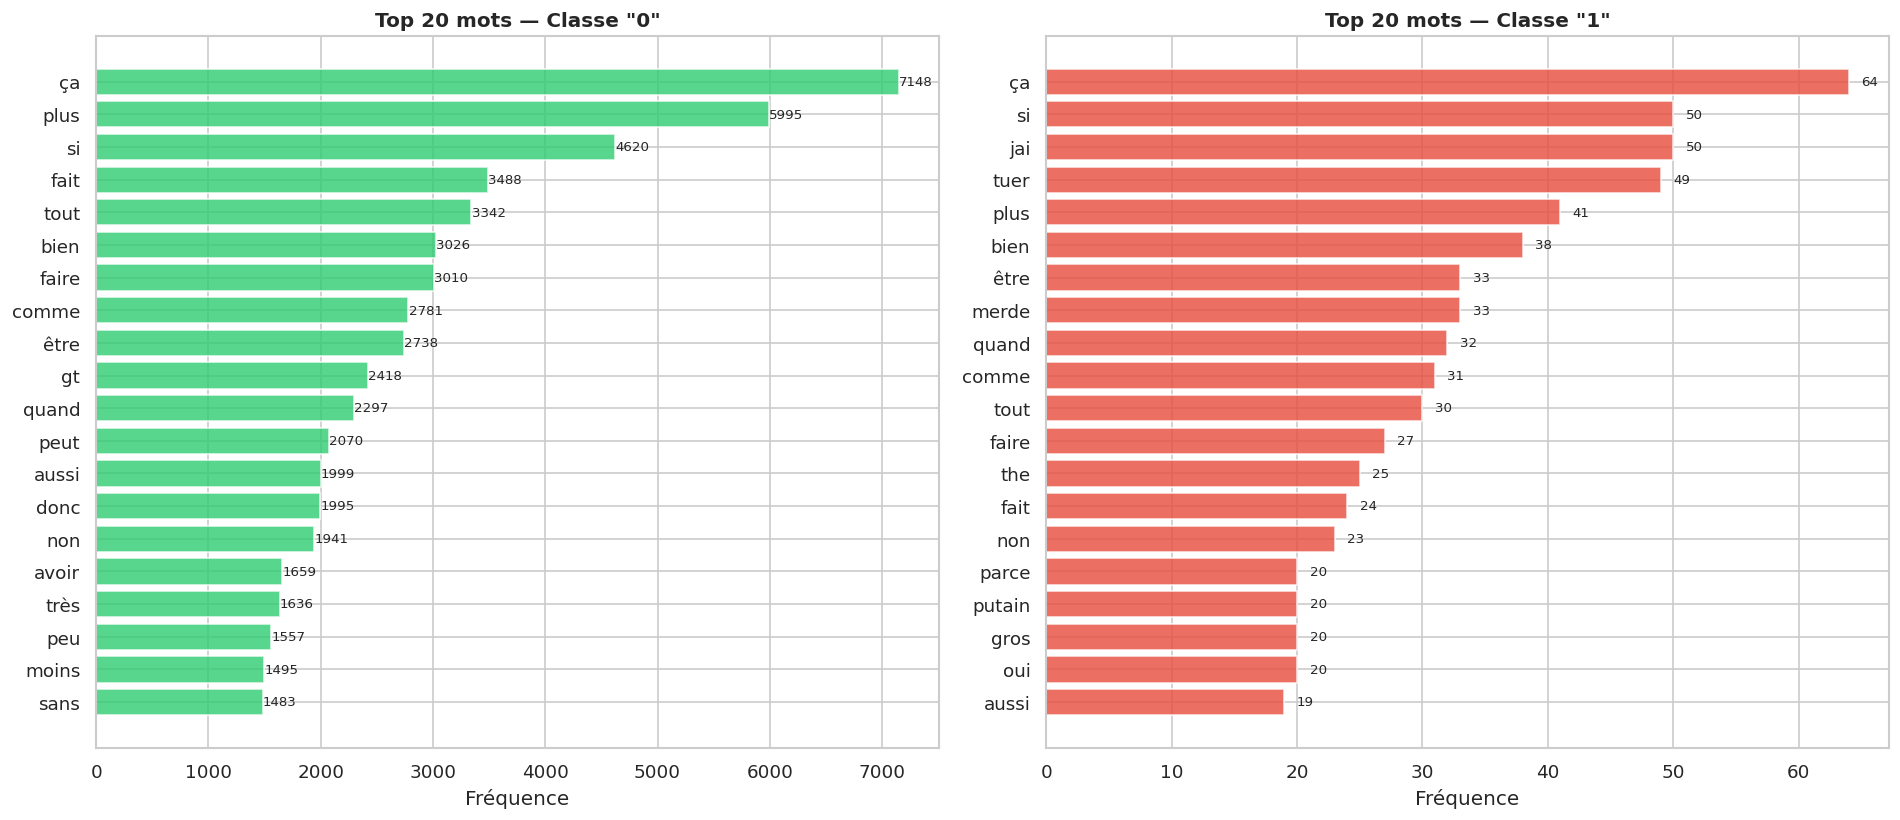

In [54]:
STOP_FR = set(stopwords.words('french'))
# Stopwords supplémentaires spécifiques aux tweets
STOP_FR.update(['rt', 'via', 'cc', 'http', 'https', 'co', 'amp', 'tweet'])

def get_top_words(texts, n=30, stop=STOP_FR):
    """Retourne les n mots les plus fréquents (hors stopwords)."""
    all_words = []
    for text in texts:
        text = re.sub(r'http\S+|@\w+|#', '', str(text).lower())
        words = re.findall(r'\b[a-záàâäéèêëîïôöùûüç]{2,}\b', text)
        all_words.extend([w for w in words if w not in stop])
    return Counter(all_words).most_common(n)

labels_unique = sorted(df[LABEL_COL].unique())

fig, axes = plt.subplots(1, len(labels_unique), figsize=(8*len(labels_unique), 7))
if len(labels_unique) == 2:
    axes = [axes] if len(labels_unique) == 1 else axes

for ax, label in zip(axes, labels_unique):
    subset = df[df[LABEL_COL] == label][TEXT_COL]
    top    = get_top_words(subset, n=20)
    words, freqs = zip(*top)
    
    color = '#E74C3C' if str(label) in ['1','haineux','hate'] else '#2ECC71'
    bars = ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, alpha=0.8)
    ax.set_title(f'Top 20 mots — Classe "{label}"', fontweight='bold')
    ax.set_xlabel('Fréquence')
    for bar, val in zip(bars, list(reversed(freqs))):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

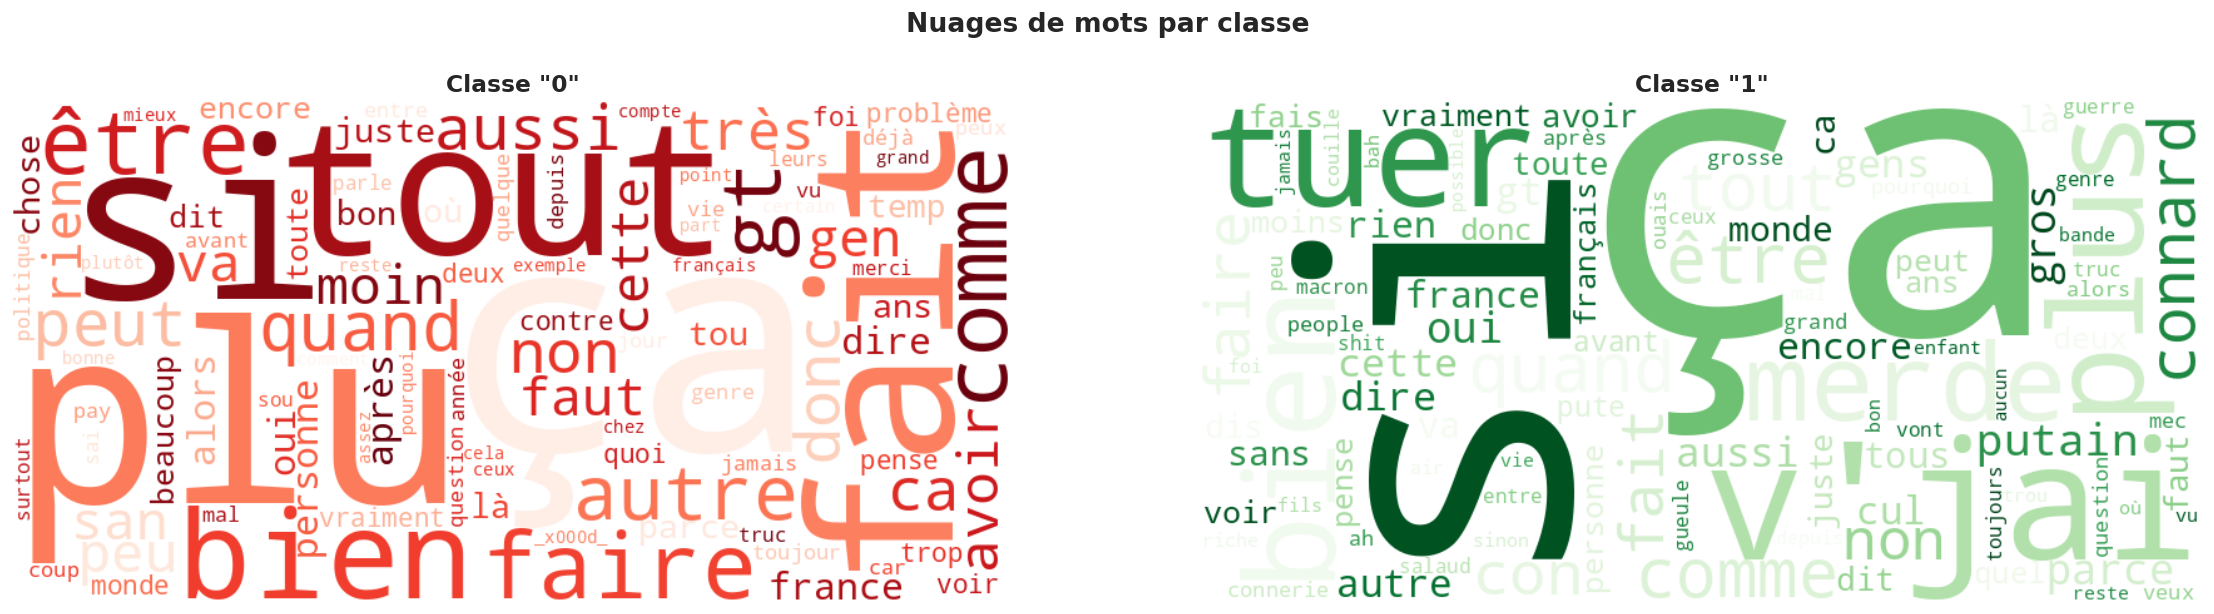

In [55]:
def make_wordcloud(texts, title, colormap='Reds'):
    combined = ' '.join(texts)
    combined = re.sub(r'http\S+|@\w+|#\w+', '', combined.lower())
    combined = re.sub(r'\b(' + '|'.join(STOP_FR) + r')\b', '', combined)
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(combined)
    return wc

fig, axes = plt.subplots(1, len(labels_unique), figsize=(10*len(labels_unique), 5))
if len(labels_unique) == 1:
    axes = [axes]

cmaps = ['Reds', 'Greens', 'Blues', 'Purples']
for ax, label, cmap in zip(axes, labels_unique, cmaps):
    subset = df[df[LABEL_COL] == label][TEXT_COL].astype(str)
    wc     = make_wordcloud(subset, str(label), colormap=cmap)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Classe "{label}"', fontsize=14, fontweight='bold')

plt.suptitle('Nuages de mots par classe', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [60]:
df2 = df[[TEXT_COL, LABEL_COL]].copy()
df2.columns

Index(['text', 'Perspective_label'], dtype='object')

In [62]:
out_dir = '/content/drive/MyDrive/TER/exports'
import os
os.makedirs(out_dir, exist_ok=True)
df2.to_excel(f'{out_dir}/reddit_nettoye.xlsx', index=False)